In [ ]:
!pip install torch torchvision matplotlib scikit-learn pillow kaggle gradio timm seaborn -q

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import transforms, models, datasets
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import os, time, copy, warnings
warnings.filterwarnings('ignore')
import timm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
#Download the dataset
!mkdir -p ~/.kaggle
!cp "kaggle (1).json" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p /content/
!unzip -q /content/chest-xray-pneumonia.zip -d /content/

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:21<00:00, 232MB/s]
100% 2.29G/2.29G [00:21<00:00, 114MB/s]


In [ ]:
#Enhanced Data Augmentation
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(10),  # تقليل الدوران
        transforms.ColorJitter(brightness=0.1, contrast=0.1),  # تقليل التباين
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),  # تقليل الإزاحة
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

In [ ]:
#Load data with improved class balancing
path = "/content/chest_xray/chest_xray"
image_datasets = {
    x: datasets.ImageFolder(os.path.join(path, x), data_transforms[x])
    for x in ['train', 'val', 'test']
}

# Calculate class counts
train_labels = [label for _, label in image_datasets['train']]
class_counts = np.bincount(train_labels)
print(f"Class counts: {class_counts}")

# Improved method for computing class weights
class_weights = 1. / torch.tensor(class_counts, dtype=torch.float)
class_weights = class_weights / class_weights.sum() * len(class_counts)
print(f"Class weights: {class_weights}")

sample_weights = class_weights[train_labels]

from torch.utils.data import WeightedRandomSampler
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

dataloaders = {
    'train': torch.utils.data.DataLoader(
        image_datasets['train'],
        batch_size=32,
        sampler=sampler,
        num_workers=2,
        pin_memory=True
    ),
    'val': torch.utils.data.DataLoader(
        image_datasets['val'],
        batch_size=32,
        shuffle=False,
        num_workers=2
    ),
    'test': torch.utils.data.DataLoader(
        image_datasets['test'],
        batch_size=32,
        shuffle=False,
        num_workers=2
    )
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes

print(f"\n📊 Dataset Statistics:")
print(f"Classes: {class_names}")
print(f"Train size: {dataset_sizes['train']}")
print(f"Validation size: {dataset_sizes['val']}")
print(f"Test size: {dataset_sizes['test']}")

Class counts: [1341 3875]
Class weights: tensor([1.4858, 0.5142])

📊 Dataset Statistics:
Classes: ['NORMAL', 'PNEUMONIA']
Train size: 5216
Validation size: 16
Test size: 624


In [ ]:
#Improved Autoencoder model
class ImprovedAutoencoder(nn.Module):
    def __init__(self, latent_dim=512):
        super(ImprovedAutoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, stride=2, padding=1),  # 112x112
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.Dropout(0.1),

            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),  # 56x56
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.Dropout(0.1),

            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),  # 28x28
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.Dropout(0.1),

            # Block 4
            nn.Conv2d(256, 512, kernel_size=3, stride=2, padding=1),  # 14x14
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            nn.Dropout(0.1),

            # Global pooling
            nn.AdaptiveAvgPool2d((7, 7)),  # 512x7x7
            nn.Flatten(),
            nn.Linear(512*7*7, 2048),
            nn.ReLU(True),
            nn.Dropout(0.2),
            nn.Linear(2048, latent_dim)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 2048),
            nn.ReLU(True),
            nn.Dropout(0.2),
            nn.Linear(2048, 512*7*7),
            nn.ReLU(True),
            nn.Unflatten(1, (512, 7, 7)),

            # Block 1
            nn.ConvTranspose2d(512, 256, kernel_size=3, stride=2, padding=1, output_padding=1),  # 14x14
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.Dropout(0.1),

            # Block 2
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1),  # 28x28
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.Dropout(0.1),

            # Block 3
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),  # 56x56
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.Dropout(0.1),

            # Block 4
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),  # 112x112
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            nn.Dropout(0.1),

            # Final block
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),  # 224x224
            nn.BatchNorm2d(16),
            nn.ReLU(True),
            nn.Conv2d(16, 3, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed, latent

    def encode(self, x):
        return self.encoder(x)

In [ ]:
#Improved Hybrid Model
class ImprovedHybridModel(nn.Module):
    def __init__(self, num_classes=2, use_pretrained=True):
        super(ImprovedHybridModel, self).__init__()

        #Use EfficientNet instead of DenseNet (more efficient)
        self.cnn_backbone = timm.create_model('efficientnet_b0',
                                             pretrained=use_pretrained,
                                             num_classes=0,  # إزالة الطبقة الأخيرة
                                             global_pool='')

        # Freeze early layers
        for param in self.cnn_backbone.parameters():
            param.requires_grad = False

        # Unfreeze last layers
        for name, param in self.cnn_backbone.named_parameters():
            if 'blocks.5' in name or 'blocks.6' in name or 'conv_head' in name or 'bn2' in name:
                param.requires_grad = True

        # Get output feature map size
        with torch.no_grad():
            test_input = torch.randn(1, 3, 224, 224)
            cnn_output = self.cnn_backbone(test_input)
            self.cnn_output_channels = cnn_output.shape[1]
            self.cnn_output_height = cnn_output.shape[2]
            self.cnn_output_width = cnn_output.shape[3]

        #Spatial LSTM to capture spatial relationships
        self.spatial_lstm = nn.LSTM(
            input_size=self.cnn_output_channels,
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        # Attention Mechanism
        self.attention = nn.Sequential(
            nn.Linear(256, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

        # Global pooling after LSTM
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Classifier with better regularization
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x, return_features=False):
        # CNN Features
        batch_size = x.size(0)
        cnn_features = self.cnn_backbone(x)  # [batch, channels, height, width]

        # Reshape for LSTM
        # [batch, channels, height, width] -> [batch, height*width, channels]
        cnn_features = cnn_features.permute(0, 2, 3, 1)  # [batch, height, width, channels]
        spatial_features = cnn_features.reshape(batch_size, -1, self.cnn_output_channels)  # [batch, seq_len, channels]

        # Spatial LSTM
        lstm_out, _ = self.spatial_lstm(spatial_features)  # [batch, seq_len, hidden*2]

        # Attention
        attention_weights = torch.softmax(self.attention(lstm_out), dim=1)
        context_vector = torch.sum(lstm_out * attention_weights, dim=1)  # [batch, hidden*2]

        # Classification
        output = self.classifier(context_vector)

        if return_features:
            return output, cnn_features, context_vector, attention_weights
        return output

In [ ]:

# Train Autoencoder
def train_autoencoder(autoencoder, dataloader, num_epochs=15):
    autoencoder = autoencoder.to(device)
    optimizer = optim.AdamW(autoencoder.parameters(), lr=1e-3, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    criterion = nn.MSELoss()

    train_losses = []

    print("Training Autoencoder...")
    for epoch in range(num_epochs):
        autoencoder.train()
        running_loss = 0.0

        for images, _ in dataloader['train']:
            images = images.to(device)

            optimizer.zero_grad()
            reconstructed, _ = autoencoder(images)
            loss = criterion(reconstructed, images)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

        scheduler.step()
        epoch_loss = running_loss / dataset_sizes['train']
        train_losses.append(epoch_loss)

        if (epoch + 1) % 5 == 0:
            print(f"Autoencoder Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, LR: {scheduler.get_last_lr()[0]:.6f}")

    return autoencoder, train_losses

In [ ]:
#Train the improved hybrid model
def train_improved_model(model, dataloaders, criterion, optimizer, num_epochs=30):
    best_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())
    patience = 7
    patience_counter = 0

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    # Multiple schedulers
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=1e-3,
        epochs=num_epochs,
        steps_per_epoch=len(dataloaders['train']),
        pct_start=0.3
    )

    for epoch in range(num_epochs):
        print(f"\n{'='*60}")
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"{'='*60}")

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    _, preds = torch.max(outputs, 1)

                    if phase == 'train':
                        loss.backward()
                        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                        optimizer.step()
                        scheduler.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            if phase == 'train':
                train_losses.append(epoch_loss)
                train_accs.append(epoch_acc.item())
            else:
                val_losses.append(epoch_loss)
                val_accs.append(epoch_acc.item())

            print(f"{phase.capitalize()}: Loss = {epoch_loss:.4f}, Acc = {epoch_acc:.4f}")

            # Save best model
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                patience_counter = 0
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'accuracy': best_acc,
                }, "/content/best_hybrid_model.pth")
                print(f"✅ New best model saved! Accuracy: {best_acc:.4f}")
            elif phase == 'val':
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"⏹️ Early stopping triggered!")
                    model.load_state_dict(best_model_wts)
                    return model, train_losses, val_losses, train_accs, val_accs

    model.load_state_dict(best_model_wts)
    return model, train_losses, val_losses, train_accs, val_accs

In [ ]:
#Main Training Pipeline
print("\n" + "="*80)
print("STARTING IMPROVED HYBRID MODEL TRAINING")
print("="*80)

# Step 1: Train Autoencoder
print("\n📦 STEP 1: Training Autoencoder...")
autoencoder = ImprovedAutoencoder(latent_dim=512)
autoencoder, ae_losses = train_autoencoder(autoencoder, dataloaders, num_epochs=15)
torch.save(autoencoder.state_dict(), "/content/chest_xray_autoencoder.pth")
print("✅ Autoencoder saved successfully!")

# Step 2: Build and train the improved hybrid model
print("\n🤖 STEP 2: Building Improved Hybrid Model...")
hybrid_model = ImprovedHybridModel(
    num_classes=2,
    use_pretrained=True
).to(device)

# Improved Loss Function
class_weights = torch.tensor([1.0, 2.0]).to(device)  # وزن معتدل أكثر
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Improved Optimizer
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, hybrid_model.parameters()),
    lr=1e-4,
    weight_decay=1e-4,
    betas=(0.9, 0.999)
)

print("\n🚀 STEP 3: Training Hybrid Model...")
hybrid_model, train_losses, val_losses, train_accs, val_accs = train_improved_model(
    model=hybrid_model,
    dataloaders=dataloaders,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=25
)


STARTING IMPROVED HYBRID MODEL TRAINING

📦 STEP 1: Training Autoencoder...
Training Autoencoder...
Autoencoder Epoch [5/15], Loss: 0.7674, LR: 0.000750
Autoencoder Epoch [10/15], Loss: 0.7319, LR: 0.000250
Autoencoder Epoch [15/15], Loss: 0.7317, LR: 0.000000
✅ Autoencoder saved successfully!

🤖 STEP 2: Building Improved Hybrid Model...


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]


🚀 STEP 3: Training Hybrid Model...

Epoch 1/25
Train: Loss = 0.4787, Acc = 0.8087
Val: Loss = 0.3784, Acc = 0.8125
✅ New best model saved! Accuracy: 0.8125

Epoch 2/25
Train: Loss = 0.1803, Acc = 0.9469
Val: Loss = 0.2672, Acc = 0.8750
✅ New best model saved! Accuracy: 0.8750

Epoch 3/25
Train: Loss = 0.1248, Acc = 0.9605
Val: Loss = 0.0609, Acc = 1.0000
✅ New best model saved! Accuracy: 1.0000

Epoch 4/25
Train: Loss = 0.1025, Acc = 0.9640
Val: Loss = 0.6541, Acc = 0.6875

Epoch 5/25
Train: Loss = 0.0974, Acc = 0.9638
Val: Loss = 0.1130, Acc = 1.0000

Epoch 6/25
Train: Loss = 0.0772, Acc = 0.9709
Val: Loss = 0.4892, Acc = 0.8125

Epoch 7/25
Train: Loss = 0.0887, Acc = 0.9666
Val: Loss = 0.1859, Acc = 0.8750

Epoch 8/25
Train: Loss = 0.0585, Acc = 0.9801
Val: Loss = 0.0721, Acc = 0.9375

Epoch 9/25
Train: Loss = 0.0544, Acc = 0.9810
Val: Loss = 0.0607, Acc = 1.0000

Epoch 10/25
Train: Loss = 0.0572, Acc = 0.9783
Val: Loss = 0.1860, Acc = 0.8750
⏹️ Early stopping triggered!


In [ ]:
# ✅ 9) Comprehensive Evaluation
def evaluate_model(model, dataloader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)

            probs = F.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return np.array(all_preds), np.array(all_labels), np.array(all_probs)

print("\n📊 STEP 4: Comprehensive Evaluation...")
all_preds, all_labels, all_probs = evaluate_model(hybrid_model, dataloaders['test'])

# Compute metrics
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

accuracy = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='binary')
roc_auc = roc_auc_score(all_labels, all_probs[:, 1])

print(f"\n📈 FINAL EVALUATION RESULTS:")
print(f"   Accuracy:   {accuracy:.4f}")
print(f"   Precision:  {precision:.4f}")
print(f"   Recall:     {recall:.4f}")
print(f"   F1-Score:   {f1:.4f}")
print(f"   ROC AUC:    {roc_auc:.4f}")

# Display detailed classification report
print("\n📋 Detailed Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))


📊 STEP 4: Comprehensive Evaluation...

📈 FINAL EVALUATION RESULTS:
   Accuracy:   0.9439
   Precision:  0.9404
   Recall:     0.9718
   F1-Score:   0.9559
   ROC AUC:    0.9836

📋 Detailed Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.95      0.90      0.92       234
   PNEUMONIA       0.94      0.97      0.96       390

    accuracy                           0.94       624
   macro avg       0.95      0.93      0.94       624
weighted avg       0.94      0.94      0.94       624



Error in feature visualization: element 0 of tensors does not require grad and does not have a grad_fn


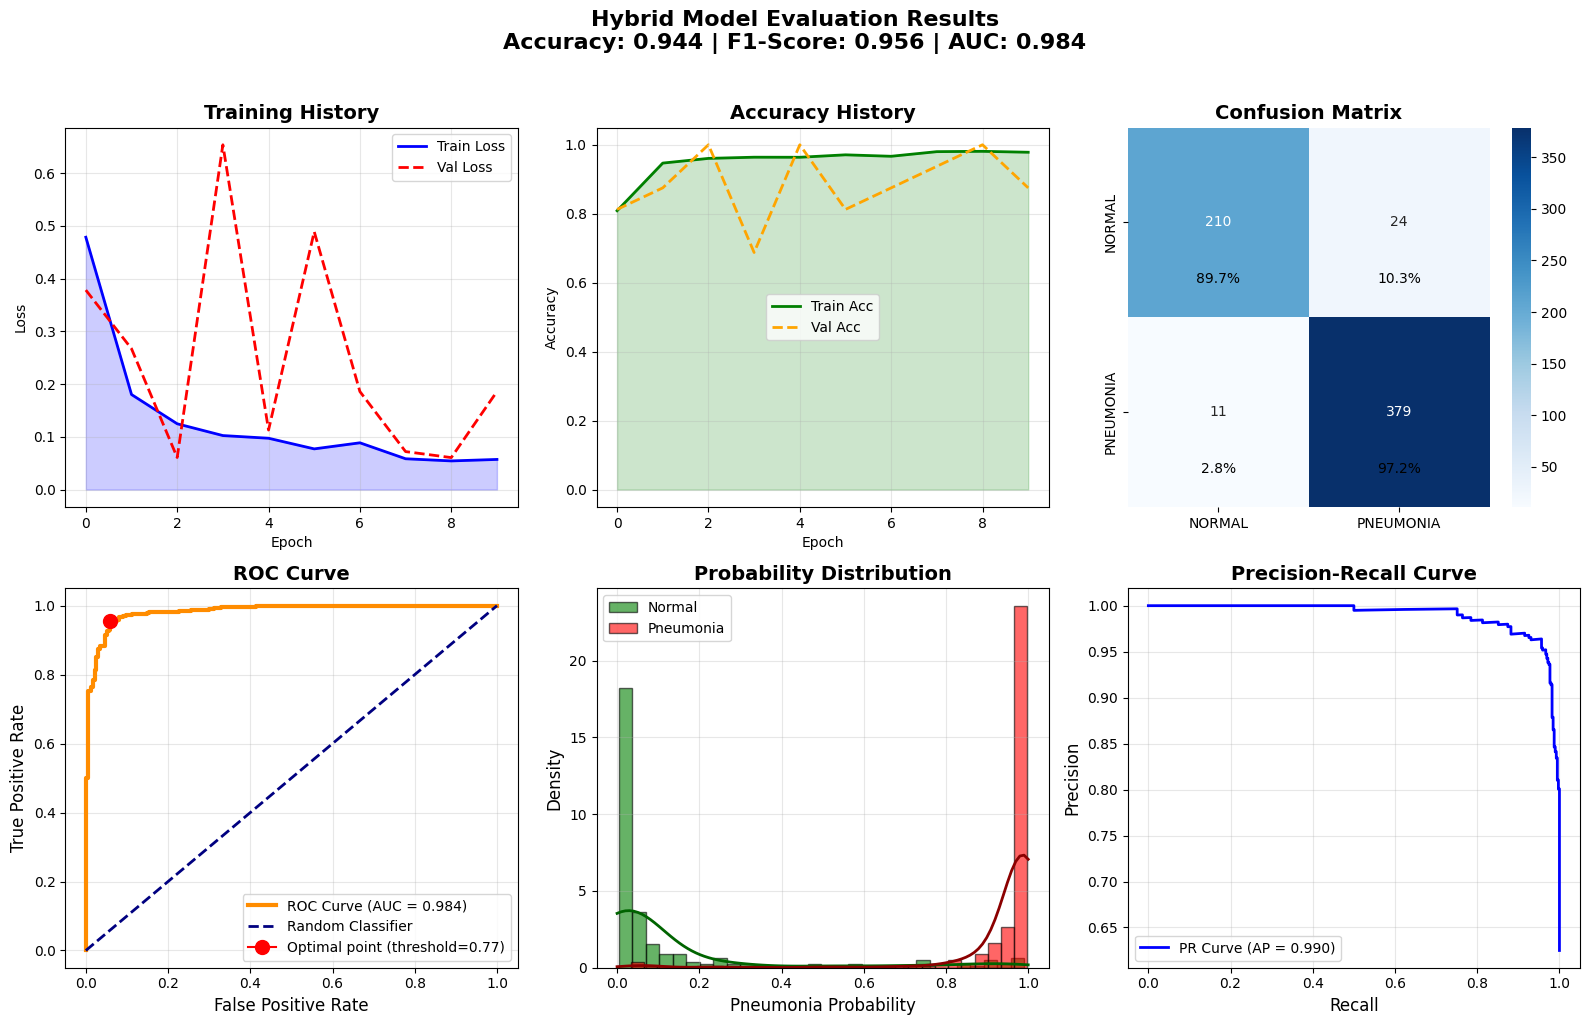


📊 Additional Visualizations:
Correct predictions: 589/624 (94.4%)
Incorrect predictions: 35/624 (5.6%)


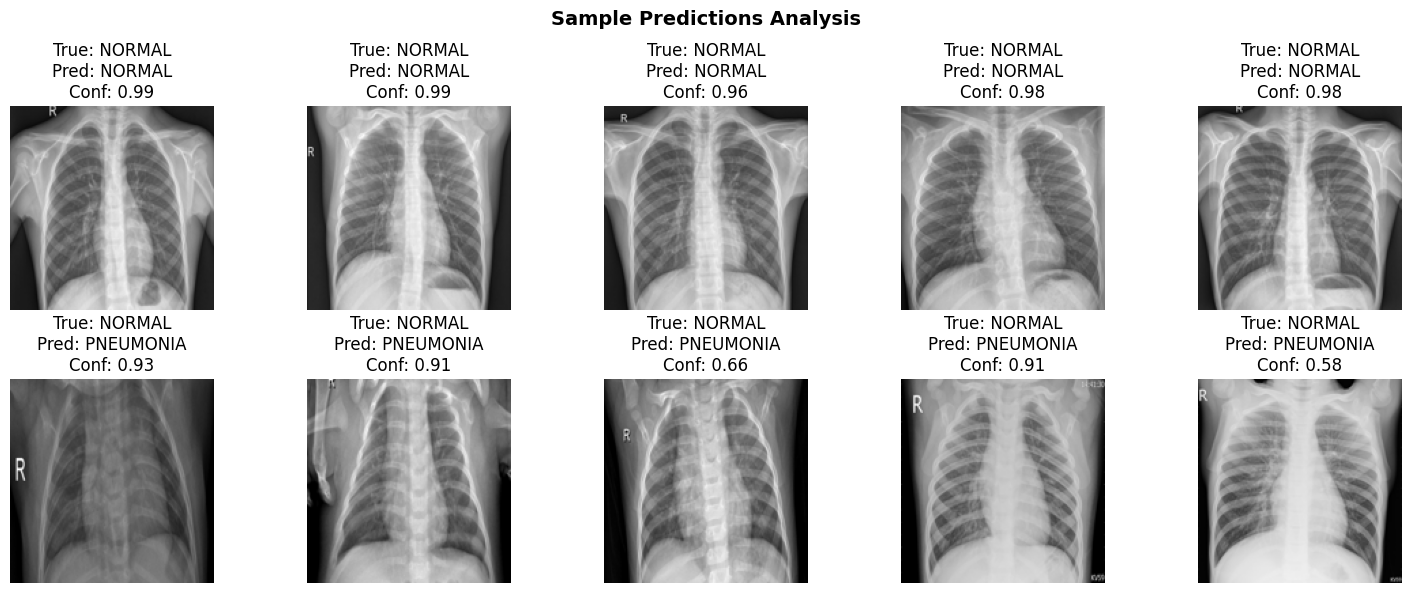

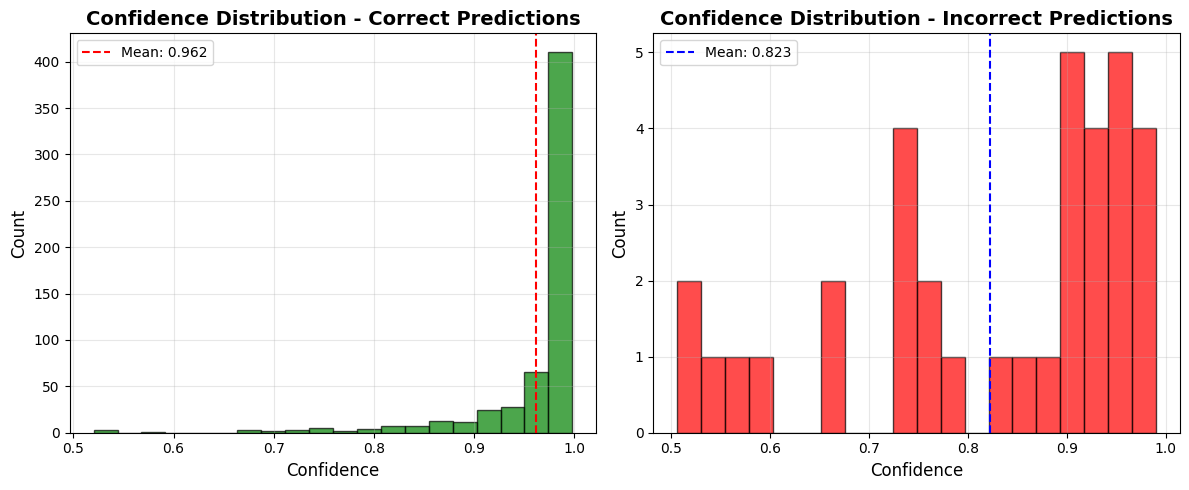


DETAILED STATISTICAL ANALYSIS

NORMAL:
  Total samples: 234
  Correct predictions: 210
  Accuracy: 0.897
  Mean pneumonia probability: 0.129
  Std pneumonia probability: 0.247
  Min pneumonia probability: 0.004
  Max pneumonia probability: 0.990

PNEUMONIA:
  Total samples: 390
  Correct predictions: 379
  Accuracy: 0.972
  Mean pneumonia probability: 0.946
  Std pneumonia probability: 0.148
  Min pneumonia probability: 0.034
  Max pneumonia probability: 0.998

ERROR ANALYSIS:
  NORMAL → PNEUMONIA: 10 occurrences


In [ ]:
# Visualization with fixed Feature Importance
from PIL import Image
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Training History
axes[0, 0].plot(train_losses, label='Train Loss', linewidth=2, color='blue')
axes[0, 0].plot(val_losses, label='Val Loss', linewidth=2, color='red', linestyle='--')
axes[0, 0].set_title('Training History', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].fill_between(range(len(train_losses)), train_losses, alpha=0.2, color='blue')

axes[0, 1].plot(train_accs, label='Train Acc', linewidth=2, color='green')
axes[0, 1].plot(val_accs, label='Val Acc', linewidth=2, color='orange', linestyle='--')
axes[0, 1].set_title('Accuracy History', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].fill_between(range(len(train_accs)), train_accs, alpha=0.2, color='green')

# Improved Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0, 2])
axes[0, 2].set_title('Confusion Matrix', fontsize=14, fontweight='bold')

# Add percentage labels
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[0, 2].text(j+0.5, i+0.8, f'{cm_percent[i, j]:.1f}%',
                       ha='center', va='center', color='black', fontsize=10)

# Improved ROC Curve
fpr, tpr, thresholds = roc_curve(all_labels, all_probs[:, 1])
axes[1, 0].plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC Curve (AUC = {roc_auc:.3f})')
axes[1, 0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[1, 0].set_xlabel('False Positive Rate', fontsize=12)
axes[1, 0].set_ylabel('True Positive Rate', fontsize=12)
axes[1, 0].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[1, 0].legend(loc="lower right")
axes[1, 0].grid(True, alpha=0.3)

# Add optimal operating point
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
axes[1, 0].plot(fpr[optimal_idx], tpr[optimal_idx], marker='o', markersize=10,
               color='red', label=f'Optimal point (threshold={optimal_threshold:.2f})')
axes[1, 0].legend()

# Probability Distributions with KDE
from scipy.stats import gaussian_kde

normal_probs = all_probs[all_labels==0, 1]
pneumonia_probs = all_probs[all_labels==1, 1]

axes[1, 1].hist(normal_probs, bins=30, alpha=0.6, label='Normal',
                color='green', density=True, edgecolor='black')
axes[1, 1].hist(pneumonia_probs, bins=30, alpha=0.6, label='Pneumonia',
                color='red', density=True, edgecolor='black')

# add KDE
if len(normal_probs) > 1:
    kde_normal = gaussian_kde(normal_probs)
    x_vals = np.linspace(0, 1, 100)
    axes[1, 1].plot(x_vals, kde_normal(x_vals), color='darkgreen', linewidth=2)

if len(pneumonia_probs) > 1:
    kde_pneumonia = gaussian_kde(pneumonia_probs)
    x_vals = np.linspace(0, 1, 100)
    axes[1, 1].plot(x_vals, kde_pneumonia(x_vals), color='darkred', linewidth=2)

axes[1, 1].set_xlabel('Pneumonia Probability', fontsize=12)
axes[1, 1].set_ylabel('Density', fontsize=12)
axes[1, 1].set_title('Probability Distribution', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# FIX: Feature Importance Visualization
try:
    # Method 1: Use gradients for importance

    hybrid_model.eval()

# Get a batch of data
    test_batch, test_labels = next(iter(dataloaders['test']))
    test_batch = test_batch[:4].to(device)  # أخذ 4 عينات فقط

# Simple method for feature importance analysis: using gradients
    test_batch.requires_grad = True

    # Forward pass
    outputs = hybrid_model(test_batch)

# Using a simplified Class Activation Maps (CAM) method

    if hasattr(hybrid_model, 'cnn_backbone'):
# Extract features from the last layer
        with torch.no_grad():
# Take a single sample
            single_image = test_batch[0:1]

# Save the gradients
            gradients = []
            activations = []

            def save_gradient(grad):
                gradients.append(grad.cpu().numpy())

            def save_activation(act):
                activations.append(act.cpu().numpy())

# Register the hooks
            handles = []

# Find the last layer of the CNN
            for name, module in hybrid_model.cnn_backbone.named_modules():
                if isinstance(module, nn.Conv2d):
                    handles.append(module.register_forward_hook(
                        lambda m, inp, out: save_activation(out)
                    ))
                    handles.append(module.register_full_backward_hook(
                        lambda m, grad_inp, grad_out: save_gradient(grad_out[0])
                    ))

            # Forward and backward pass
            output = hybrid_model(single_image)
            predicted_class = output.argmax(dim=1).item()

            # Zero gradients
            hybrid_model.zero_grad()

            # Create one-hot encoding
            one_hot = torch.zeros_like(output)
            one_hot[0, predicted_class] = 1

            # Backward pass
            output.backward(gradient=one_hot)

            # Remove the hooks
            for handle in handles:
                handle.remove()

            if activations and gradients:
                # Computing Class Activation Map (CAM)
                activations = activations[-1]  # Getting the last activation
                gradients = gradients[-1]      # Getting the last gradient


                # Calculating the weights

                weights = np.mean(gradients, axis=(2, 3))

                # Generating the CAM

                cam = np.zeros(activations.shape[2:], dtype=np.float32)
                for i, w in enumerate(weights[0]):
                    cam += w * activations[0, i]

                cam = np.maximum(cam, 0)
                cam = (cam - cam.min()) / (cam.max() - cam.min())

                # Displaying the CAM
                ax_img = axes[1, 2].imshow(cam, cmap='jet', alpha=0.8)
                axes[1, 2].set_title('Class Activation Map (CAM)', fontsize=14, fontweight='bold')
                axes[1, 2].set_xlabel('Width')
                axes[1, 2].set_ylabel('Height')
                plt.colorbar(ax_img, ax=axes[1, 2])

            else:
                # If gradients are not available, display alternative information
                 # Compute the average class probabilities
                class_avg_probs = all_probs.mean(axis=0)
                bars = axes[1, 2].bar(range(len(class_names)), class_avg_probs,
                                     color=['green', 'red'], alpha=0.7)
                axes[1, 2].set_title('Average Class Probabilities', fontsize=14, fontweight='bold')
                axes[1, 2].set_xlabel('Class')
                axes[1, 2].set_ylabel('Average Probability')
                axes[1, 2].set_xticks(range(len(class_names)))
                axes[1, 2].set_xticklabels(class_names)

                for bar, prob in zip(bars, class_avg_probs):
                    height = bar.get_height()
                    axes[1, 2].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                                   f'{prob:.3f}', ha='center', va='bottom')

    else:
        # If there is no CNN backbone, display statistical information
        # Analyze the error distribution
        errors = all_preds != all_labels
        error_rate_by_class = []

        for class_idx in range(len(class_names)):
            class_mask = all_labels == class_idx
            if np.sum(class_mask) > 0:
                error_rate = np.sum(errors[class_mask]) / np.sum(class_mask)
                error_rate_by_class.append(error_rate)

        bars = axes[1, 2].bar(class_names, error_rate_by_class,
                             color=['green', 'red'], alpha=0.7)
        axes[1, 2].set_title('Error Rate by Class', fontsize=14, fontweight='bold')
        axes[1, 2].set_xlabel('Class')
        axes[1, 2].set_ylabel('Error Rate')

        for bar, rate in zip(bars, error_rate_by_class):
            height = bar.get_height()
            axes[1, 2].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                           f'{rate:.3f}', ha='center', va='bottom')

except Exception as e:
    print(f"Error in feature visualization: {e}")

# Alternative: Display the Precision-Recall curve
    from sklearn.metrics import precision_recall_curve, average_precision_score

    precision, recall, _ = precision_recall_curve(all_labels, all_probs[:, 1])
    avg_precision = average_precision_score(all_labels, all_probs[:, 1])

    axes[1, 2].plot(recall, precision, color='blue', lw=2,
                   label=f'PR Curve (AP = {avg_precision:.3f})')
    axes[1, 2].set_xlabel('Recall', fontsize=12)
    axes[1, 2].set_ylabel('Precision', fontsize=12)
    axes[1, 2].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3)

# Adding general information
plt.suptitle(f'Hybrid Model Evaluation Results\nAccuracy: {accuracy:.3f} | F1-Score: {f1:.3f} | AUC: {roc_auc:.3f}',
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('/content/hybrid_model_results_comprehensive.png', dpi=300, bbox_inches='tight')
plt.show()

# Adding additional visualizations
print("\n📊 Additional Visualizations:")

# 1. Visualize correctly and incorrectly classified samples
fig2, axes2 = plt.subplots(2, 5, figsize=(15, 6))
correct_indices = np.where(all_preds == all_labels)[0]
incorrect_indices = np.where(all_preds != all_labels)[0]

print(f"Correct predictions: {len(correct_indices)}/{len(all_labels)} ({len(correct_indices)/len(all_labels)*100:.1f}%)")
print(f"Incorrect predictions: {len(incorrect_indices)}/{len(all_labels)} ({len(incorrect_indices)/len(all_labels)*100:.1f}%)")

# Display correctly classified samples
for i in range(5):
    if i < len(correct_indices):
        idx = correct_indices[i]

        # Load the original image
        img_path = image_datasets['test'].samples[idx][0]
        img = Image.open(img_path).convert('RGB')
        img = img.resize((150, 150))

        axes2[0, i].imshow(img)
        axes2[0, i].set_title(f"True: {class_names[all_labels[idx]]}\nPred: {class_names[all_preds[idx]]}\nConf: {all_probs[idx, all_preds[idx]]:.2f}")
        axes2[0, i].axis('off')

        # Add border color based on the classification
        border_color = 'green' if all_preds[idx] == 0 else 'red'
        for spine in axes2[0, i].spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(3)

# Display incorrectly classified samples
for i in range(5):
    if i < len(incorrect_indices):
        idx = incorrect_indices[i]

        # Load the original image
        img_path = image_datasets['test'].samples[idx][0]
        img = Image.open(img_path).convert('RGB')
        img = img.resize((150, 150))

        axes2[1, i].imshow(img)
        axes2[1, i].set_title(f"True: {class_names[all_labels[idx]]}\nPred: {class_names[all_preds[idx]]}\nConf: {all_probs[idx, all_preds[idx]]:.2f}")
        axes2[1, i].axis('off')

        # Add border color based on the classification
        border_color = 'red'  # Always red for errors
        for spine in axes2[1, i].spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(3)

axes2[0, 0].set_ylabel('Correct Predictions', fontsize=12, fontweight='bold')
axes2[1, 0].set_ylabel('Incorrect Predictions', fontsize=12, fontweight='bold')
plt.suptitle('Sample Predictions Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Analyze prediction confidence
fig3, axes3 = plt.subplots(1, 2, figsize=(12, 5))

# Confidence distribution for correct classifications
correct_confidences = all_probs[all_preds == all_labels][range(len(all_preds[all_preds == all_labels])),
                                                         all_preds[all_preds == all_labels]]
axes3[0].hist(correct_confidences, bins=20, alpha=0.7, color='green', edgecolor='black')
axes3[0].axvline(x=correct_confidences.mean(), color='red', linestyle='--',
                label=f'Mean: {correct_confidences.mean():.3f}')
axes3[0].set_xlabel('Confidence', fontsize=12)
axes3[0].set_ylabel('Count', fontsize=12)
axes3[0].set_title('Confidence Distribution - Correct Predictions', fontsize=14, fontweight='bold')
axes3[0].legend()
axes3[0].grid(True, alpha=0.3)

# Confidence distribution for incorrect classifications
if len(incorrect_indices) > 0:
    incorrect_confidences = all_probs[all_preds != all_labels][range(len(all_preds[all_preds != all_labels])),
                                                               all_preds[all_preds != all_labels]]
    axes3[1].hist(incorrect_confidences, bins=20, alpha=0.7, color='red', edgecolor='black')
    axes3[1].axvline(x=incorrect_confidences.mean(), color='blue', linestyle='--',
                    label=f'Mean: {incorrect_confidences.mean():.3f}')
    axes3[1].set_xlabel('Confidence', fontsize=12)
    axes3[1].set_ylabel('Count', fontsize=12)
    axes3[1].set_title('Confidence Distribution - Incorrect Predictions', fontsize=14, fontweight='bold')
    axes3[1].legend()
else:
    axes3[1].text(0.5, 0.5, 'No incorrect predictions!',
                 ha='center', va='center', transform=axes3[1].transAxes, fontsize=14)

axes3[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Detailed statistical report
print("\n" + "="*60)
print("DETAILED STATISTICAL ANALYSIS")
print("="*60)

# Statistics by class
for class_idx, class_name in enumerate(class_names):
    class_mask = all_labels == class_idx
    class_correct = np.sum((all_preds == all_labels)[class_mask])
    class_total = np.sum(class_mask)
    class_accuracy = class_correct / class_total if class_total > 0 else 0

    print(f"\n{class_name.upper()}:")
    print(f"  Total samples: {class_total}")
    print(f"  Correct predictions: {class_correct}")
    print(f"  Accuracy: {class_accuracy:.3f}")

    # Probability distribution
    if class_total > 0:
        class_probs = all_probs[class_mask, 1]
        print(f"  Mean pneumonia probability: {class_probs.mean():.3f}")
        print(f"  Std pneumonia probability: {class_probs.std():.3f}")
        print(f"  Min pneumonia probability: {class_probs.min():.3f}")
        print(f"  Max pneumonia probability: {class_probs.max():.3f}")

# Error analysis
if len(incorrect_indices) > 0:
    print("\nERROR ANALYSIS:")
    error_types = {}
    for idx in incorrect_indices[:10]:  # Analyze only the first 10 errors
        true_label = class_names[all_labels[idx]]
        pred_label = class_names[all_preds[idx]]
        error_key = f"{true_label} → {pred_label}"
        error_types[error_key] = error_types.get(error_key, 0) + 1

    for error, count in error_types.items():
        print(f"  {error}: {count} occurrences")

In [ ]:
# Save the final model
torch.save({
    'model_state_dict': hybrid_model.state_dict(),
    'autoencoder_state_dict': autoencoder.state_dict(),
    'class_names': class_names,
    'train_history': {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accs': train_accs,
        'val_accs': val_accs
    },
    'test_metrics': {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc
    },
    'model_config': {
        'model_type': 'ImprovedHybridModel',
        'input_size': 224,
        'num_classes': 2
    }
}, '/content/hybrid_cnn_lstm_model_final.pth')

print("\n💾 Models saved successfully!")
print("✅ Autoencoder: /content/chest_xray_autoencoder.pth")
print("✅ Hybrid Model: /content/hybrid_cnn_lstm_model_final.pth")


💾 Models saved successfully!
✅ Autoencoder: /content/chest_xray_autoencoder.pth
✅ Hybrid Model: /content/hybrid_cnn_lstm_model_final.pth


In [ ]:
# Simple and efficient Gradio interface
import gradio as gr
from PIL import Image

class SimplePneumoniaDetector:
    def __init__(self, model_path='/content/hybrid_cnn_lstm_model_final.pth'):
        # Load the model
        checkpoint = torch.load(model_path, map_location=device, weights_only=False)

        # Reconstruct the model
        self.model = ImprovedHybridModel(num_classes=2, use_pretrained=False).to(device)
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.model.eval()

        self.class_names = checkpoint['class_names']
        self.metrics = checkpoint['test_metrics']
        self.transform = data_transforms['test']

    def predict(self, image):
        # Transform the image
        if isinstance(image, np.ndarray):
            image = Image.fromarray(image.astype('uint8'))

        image_tensor = self.transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            output = self.model(image_tensor)
            probs = F.softmax(output, dim=1)[0]

            predicted_idx = torch.argmax(probs).item()
            predicted_class = self.class_names[predicted_idx]
            confidence = probs[predicted_idx].item()

        return predicted_class, confidence, probs.cpu().numpy()

# Initialize the detector
detector = SimplePneumoniaDetector()

# Gradio function
def gradio_predict(image):
    if image is None:
        return "Please upload an X-ray image", None, None

    predicted_class, confidence, probs = detector.predict(image)

    # Generate the report

    report = f"""
    ## 🏥 **Pneumonia Detection Result**

    ### 📋 **Diagnosis:** {predicted_class}
    ### 🔍 **Confidence:** {confidence:.2%}

    ### 📊 **Probabilities:**
    - **Normal:** {probs[0]:.2%}
    - **Pneumonia:** {probs[1]:.2%}

    ### 📈 **Model Performance:**
    - **Accuracy:** {detector.metrics['accuracy']:.2%}
    - **F1-Score:** {detector.metrics['f1']:.2%}
    - **ROC AUC:** {detector.metrics['roc_auc']:.4f}

    ### 💡 **Interpretation:**
    {f"**🟢 Normal** - No signs of pneumonia detected." if predicted_class == 'NORMAL' else
      f"**🔴 Pneumonia** - Abnormalities detected. Please consult a doctor."}

    ---
    *Note: This is an AI-assisted tool. Always consult with healthcare professionals.*
    """

    # Create a probability chart
    fig, ax = plt.subplots(figsize=(6, 4))
    colors = ['#4CAF50', '#FF5252']
    bars = ax.bar(['Normal', 'Pneumonia'], probs, color=colors, edgecolor='black')
    ax.set_ylim([0, 1])
    ax.set_ylabel('Probability')
    ax.set_title('Classification Probabilities')

    for bar, prob in zip(bars, probs):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{prob:.2%}', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()

    return report, fig, f"Prediction: {predicted_class} (Confidence: {confidence:.2%})"

# Create the Gradio interface
with gr.Blocks(theme=gr.themes.Soft(), title="AI Pneumonia Detector") as demo:
    gr.Markdown("""
    # 🏥 **AI-Powered Pneumonia Detection System**
    ### *Advanced Deep Learning for Chest X-Ray Analysis*
    """)

    with gr.Row():
        with gr.Column(scale=1):
            gr.Markdown("### 📤 Upload X-Ray Image")
            image_input = gr.Image(type="pil", label="Chest X-Ray", height=300)

            analyze_btn = gr.Button("🔍 Analyze Image", variant="primary", size="lg")
            clear_btn = gr.Button("🔄 Clear", size="lg")

            gr.Markdown("""
            ### 📝 **Instructions:**
            1. Upload a frontal chest X-ray image
            2. Click 'Analyze Image'
            3. Review the AI diagnosis report

            ### 🔬 **Model Info:**
            - **Architecture:** Hybrid CNN-LSTM
            - **Training:** Transfer Learning + Fine-tuning
            - **Dataset:** 5,856 labeled X-rays
            """)

        with gr.Column(scale=2):
            gr.Markdown("### 📋 **Diagnosis Report**")
            report_output = gr.Markdown()

            gr.Markdown("### 📊 **Visualization**")
            plot_output = gr.Plot()

            status_output = gr.Textbox(label="Status", interactive=False)

    # Examples
    gr.Examples(
        examples=[
            ["/content/chest_xray/chest_xray/test/NORMAL/IM-0001-0001.jpeg"],
            ["/content/chest_xray/chest_xray/test/PNEUMONIA/person100_bacteria_475.jpeg"],
            ["/content/chest_xray/chest_xray/val/NORMAL/NORMAL2-IM-1430-0001.jpeg"]
        ],
        inputs=image_input,
        outputs=[report_output, plot_output, status_output],
        fn=gradio_predict,
        cache_examples=True
    )

    # Events
    analyze_btn.click(
        fn=gradio_predict,
        inputs=image_input,
        outputs=[report_output, plot_output, status_output]
    )

    clear_btn.click(
        fn=lambda: (None, None, None, None),
        inputs=[],
        outputs=[image_input, report_output, plot_output, status_output]
    )

    gr.Markdown("""
    ---
    **⚠️ Medical Disclaimer:** This AI tool is for educational and research purposes only.
    It should not be used as a substitute for professional medical advice, diagnosis, or treatment.
    """)

print("\n🚀 Launching AI Interface...")
print("📊 Model Performance Summary:")
print(f"   • Accuracy: {accuracy:.2%}")
print(f"   • F1-Score: {f1:.2%}")
print(f"   • ROC AUC: {roc_auc:.4f}")

demo.launch(share=True, debug=True)



🚀 Launching AI Interface...
📊 Model Performance Summary:
   • Accuracy: 94.39%
   • F1-Score: 95.59%
   • ROC AUC: 0.9836
Caching examples at: '/content/.gradio/cached_examples/16'
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://260177c2756b90a4b4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
